# ResNet Custom Model for Drone Acoustic Detection

In [ ]:
!pip install torchmetrics pandas datasets numpy torchmetrics scikit-learn seaborn torchcodec torchaudio librosa ipywidgets torchvision wandb

In [3]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from datasets import load_from_disk, load_dataset, concatenate_datasets, DatasetDict
import torchmetrics
from tqdm import tqdm
import numpy as np
import random
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
from IPython.lib.display import Audio as AudioDisplay

## Configurations

In [51]:
SEED = 42
BATCH_SIZE = 64
NUM_WORKERS = 24
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1.00E-01
MODEL_SAVE_PATH = "models/resnet_P1.pt"
EPOCHS=5

# Set seeds for reproducibility between runs
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

print(f"Using device: {DEVICE}")
print(f"Number of workers: {NUM_WORKERS}")

Using device: cuda
Number of workers: 24


## Dataset & Collate function

In [52]:
dataset = load_from_disk("../../dataset/ds_1_MAT-AllTEST_melspectogram")
dataset = dataset.with_format("torch", columns=["audio", "label"])

print("\nDataset splits:")
print({k: v.shape for k, v in dataset.items()})

print("\nDataset features:")
print(dataset["train"].features)

Loading dataset from disk:   0%|          | 0/43 [00:00<?, ?it/s]


Dataset splits:
{'train': (636820, 2), 'val': (158828, 2)}

Dataset features:
{'audio': List(List(List(Value('float64')))), 'label': ClassLabel(names=['other', 'drone'])}


In [53]:
print(dataset["train"][1]["audio"].shape, dataset["train"][0]["label"])

torch.Size([1, 128, 32]) tensor(1)


In [54]:
def convert_to_mel_spectrogram(data):
    mel = librosa.feature.melspectrogram(
        y=data,
        sr=16000,
        n_fft=1025,
        hop_length=256,
        n_mels=128,
        fmin=20,
        fmax=8000,
        power=2.0
    )
    # Convert to log scale (dB)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalize
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    # Convert to torch tensor: [1, n_mels, time]
    mel_db = torch.tensor(mel_db).unsqueeze(0)

    return mel_db


def collate_fn(batch):
    inputs = []
    labels = []

    for item in batch:
        inputs.append(item["audio"])
        labels.append(item["label"])

    # Pad time dimension so all samples in batch have same T
    inputs = torch.nn.utils.rnn.pad_sequence(
        inputs, batch_first=True
    )

    labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

    return inputs, labels


train_loader = DataLoader(dataset["train"], batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
valid_loader = DataLoader(dataset["val"], batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f"\nCreated DataLoaders with Batch Size: {BATCH_SIZE}")

# Check a sample batch
try:
    sample_x, sample_y = next(iter(train_loader))
    print(f"Sample batch shape - X: {sample_x.shape}, Y: {sample_y.shape}")
except Exception as e:
    print(f"Could not load a sample batch: {e}")


Created DataLoaders with Batch Size: 64
Sample batch shape - X: torch.Size([64, 1, 128, 32]), Y: torch.Size([64, 1])


## Model Definition

In [55]:
from model import AudioResNet

model = AudioResNet().to(DEVICE)

## Training Setup

In [56]:
criterion = nn.BCEWithLogitsLoss()

class LabelSmoothingBCELoss(nn.Module):
    """
    Custom loss function that applies label smoothing.
    """
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        targets = targets * (1 - self.smoothing) + self.smoothing / 2
        return nn.functional.binary_cross_entropy_with_logits(logits, targets)

criterion = LabelSmoothingBCELoss(smoothing=0.15)  # Try 0.1 to 0.2
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

metric_acc = torchmetrics.classification.BinaryAccuracy().to(DEVICE)

In [57]:
best_val_acc = 0.0
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

print("\nStarting training...")

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    metric_acc.reset()

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", unit="batch")

    for x, y in train_pbar:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        out = model(x)
        loss = criterion(out, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        running_train_loss += loss.item() * x.size(0)
        metric_acc.update(out, y)

        train_pbar.set_postfix(loss=loss.item())

    scheduler.step()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = metric_acc.compute().item()

    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)

    model.eval()
    running_val_loss = 0.0
    metric_acc.reset()

    valid_pbar = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]", unit="batch")

    with torch.no_grad():
        for x, y in valid_pbar:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            out = model(x)
            loss = criterion(out, y)

            running_val_loss += loss.item() * x.size(0)
            metric_acc.update(out, y)

            valid_pbar.set_postfix(loss=loss.item())

    epoch_val_loss = running_val_loss / len(valid_loader.dataset)
    epoch_val_acc = metric_acc.compute().item()

    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | "
          f"Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc:.4f}")

    # Save the best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Saved new best model to {MODEL_SAVE_PATH} (Val Acc: {best_val_acc:.4f})")

print("\nTraining complete.")


Starting training...


Epoch 1/5 [Valid]: 100%|██████████| 2482/2482 [00:18<00:00, 130.98batch/s, loss=0.267]



Epoch 1/5 | Train Loss: 0.2950 | Train Acc: 0.9840 | Val Loss: 0.2825 | Val Acc: 0.9902
Saved new best model to models/resnet_P1.pt (Val Acc: 0.9902)


Epoch 2/5 [Valid]: 100%|██████████| 2482/2482 [00:20<00:00, 121.33batch/s, loss=0.268]



Epoch 2/5 | Train Loss: 0.2802 | Train Acc: 0.9930 | Val Loss: 0.2815 | Val Acc: 0.9907
Saved new best model to models/resnet_P1.pt (Val Acc: 0.9907)


...


Epoch 3/5 | Train Loss: 0.2761 | Train Acc: 0.9954 | Val Loss: 0.2757 | Val Acc: 0.9944
Saved new best model to models/resnet_P1.pt (Val Acc: 0.9944)


Epoch 4/5 [Valid]: 100%|██████████| 2482/2482 [00:18<00:00, 136.89batch/s, loss=0.267]



Epoch 4/5 | Train Loss: 0.2730 | Train Acc: 0.9973 | Val Loss: 0.2749 | Val Acc: 0.9947
Saved new best model to models/resnet_P1.pt (Val Acc: 0.9947)


Epoch 5/5 [Valid]: 100%|██████████| 2482/2482 [00:18<00:00, 135.73batch/s, loss=0.266]



Epoch 5/5 | Train Loss: 0.2710 | Train Acc: 0.9985 | Val Loss: 0.2728 | Val Acc: 0.9960
Saved new best model to models/resnet_P1.pt (Val Acc: 0.9960)

Training complete.


## Training Visualization

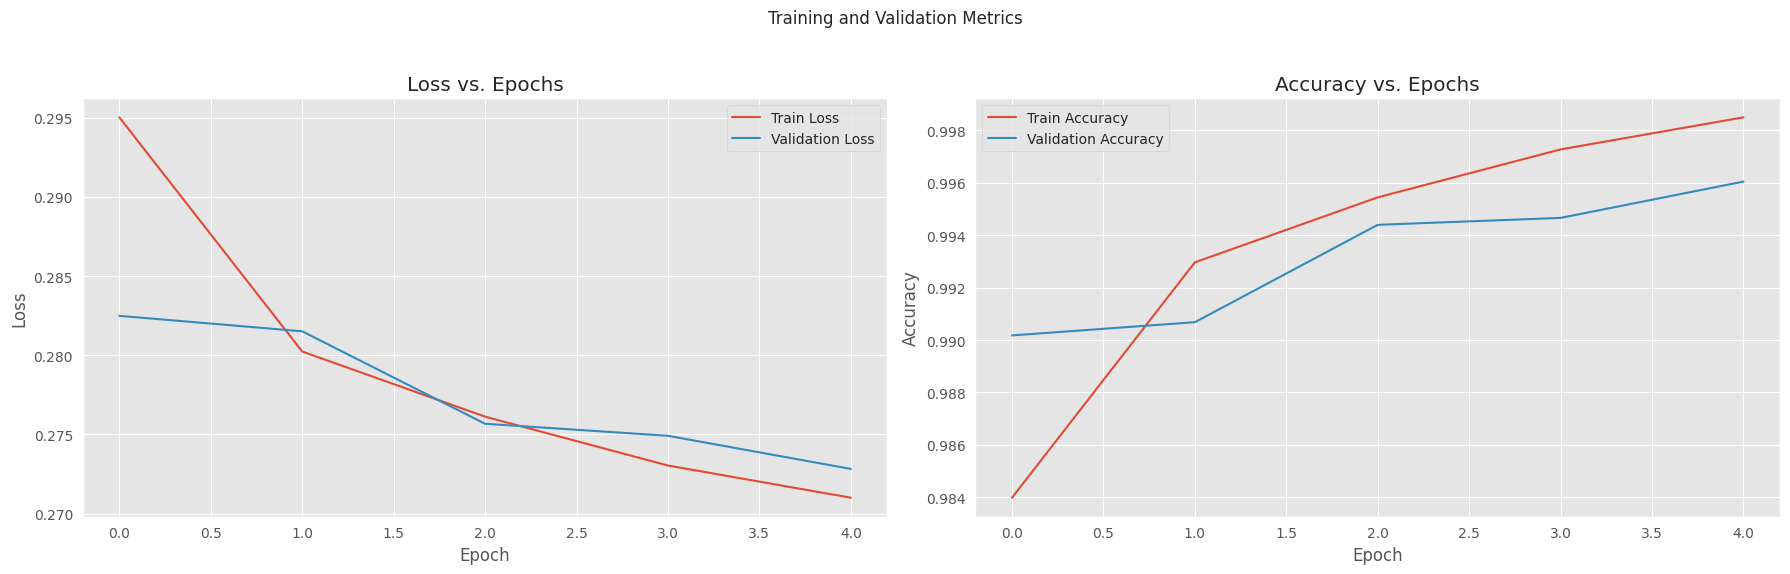

In [58]:
if history["train_loss"]:
    plt.style.use("ggplot")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot Loss
    ax1.plot(history["train_loss"], label="Train Loss")
    ax1.plot(history["val_loss"], label="Validation Loss")
    ax1.set_title("Loss vs. Epochs")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    # Plot Accuracy
    ax2.plot(history["train_acc"], label="Train Accuracy")
    ax2.plot(history["val_acc"], label="Validation Accuracy")
    ax2.set_title("Accuracy vs. Epochs")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()

    plt.suptitle("Training and Validation Metrics")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### Model loading and Test Evaluation

Change LOAD_MODEL_PATH to load a different model if needed

In [59]:
LOAD_MODEL_PATH = MODEL_SAVE_PATH
print(f"Loading best model from {LOAD_MODEL_PATH}...")
model = model.to(DEVICE)
model.eval()
print("Loaded best model and set to eval mode.")

Loading best model from models/resnet_P1.pt...
Loaded best model and set to eval mode.


## Evaluation on Custom Test Sets

In [60]:
ds_all_tests = load_dataset("Hibou-Foundation/all_tests_ds_3")

In [61]:
import librosa
def convert_to_mel_spectrogram(data):
    mel = librosa.feature.melspectrogram(
        y=data,
        sr=16000,
        n_fft=1025,
        hop_length=256,
        n_mels=128,
        fmin=20,
        fmax=8000,
        power=2.0
    )
     # Convert to log scale (dB)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalize
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    # Convert to torch tensor: [1, n_mels, time]
    mel_db = torch.tensor(mel_db).unsqueeze(0)

    return mel_db


def collate_fn_librosa_test(batch):
    inputs = []
    labels = []

    for item in batch:
        waveforme = item["audio"]["array"]
        wave = convert_to_mel_spectrogram(waveforme)
        inputs.append(wave)
        labels.append(item["label"])

    # Pad time dimension so all samples in batch have same T
    inputs = torch.nn.utils.rnn.pad_sequence(
        inputs, batch_first=True
    )

    labels = torch.tensor(labels, dtype=torch.float32)

    return inputs, labels

In [62]:
dataloaders = {}
for split in ds_all_tests.keys():
    ds = ds_all_tests[split]
    dataloaders[split] = DataLoader(
        ds,
        batch_size=1,
        shuffle=False,
        num_workers=1,
        collate_fn=collate_fn_librosa_test,
    )
dataloaders

{'drone_test': <torch.utils.data.dataloader.DataLoader at 0x7f751a79a350>,
 'drone_test_2': <torch.utils.data.dataloader.DataLoader at 0x7f764f23bd50>,
 'parabole1': <torch.utils.data.dataloader.DataLoader at 0x7f764f23bb50>,
 'parabole2': <torch.utils.data.dataloader.DataLoader at 0x7f764f23b950>,
 'parabole3': <torch.utils.data.dataloader.DataLoader at 0x7f764f23bc50>,
 'parabole4': <torch.utils.data.dataloader.DataLoader at 0x7f764e5fc250>,
 'parabole5': <torch.utils.data.dataloader.DataLoader at 0x7f764e5ffe50>,
 'parabole6': <torch.utils.data.dataloader.DataLoader at 0x7f764e5fe450>,
 'parabole7': <torch.utils.data.dataloader.DataLoader at 0x7f764e5fc050>}

In [63]:
results = {}
for split, loader in dataloaders.items():
    y_true, y_pred = [], []
    for x, y in tqdm(loader, desc=f"Testing {split}"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        y_pred.extend(preds.cpu().numpy().flatten())
        y_true.extend(y.cpu().numpy().flatten())
    results[split] = (y_true, y_pred)

Testing parabole7: 100%|██████████| 7953/7953 [00:23<00:00, 333.36it/s]


In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_pred)
    except:
        auc = float("nan")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
    }

metrics = {}
for split, (y_true, y_pred) in results.items():
    metrics[split] = compute_metrics(y_true, y_pred)
    print(split, metrics[split])

drone_test {'accuracy': 0.8913773796192609, 'precision': 0.9965397923875432, 'recall': 0.75, 'f1': 0.8558692421991084, 'auc': 0.8740176817288802, 'confusion_matrix': array([[508,   1],
       [ 96, 288]])}
drone_test_2 {'accuracy': 0.9575757575757575, 'precision': 1.0, 'recall': 0.9575606276747504, 'f1': 0.9783202769174713, 'auc': 0.9787803138373752, 'confusion_matrix': array([[   1,    0],
       [ 119, 2685]])}
parabole1 {'accuracy': 0.943089430894309, 'precision': 0.9176470588235294, 'recall': 1.0, 'f1': 0.9570552147239264, 'auc': 0.9222222222222223, 'confusion_matrix': array([[38,  7],
       [ 0, 78]])}
parabole2 {'accuracy': 0.9647058823529412, 'precision': 0.9516129032258065, 'recall': 1.0, 'f1': 0.9752066115702479, 'auc': 0.9423076923076923, 'confusion_matrix': array([[23,  3],
       [ 0, 59]])}
parabole3 {'accuracy': 0.9563636363636364, 'precision': 1.0, 'recall': 0.9466666666666667, 'f1': 0.9726027397260274, 'auc': 0.9733333333333334, 'confusion_matrix': array([[ 50,   0],
 

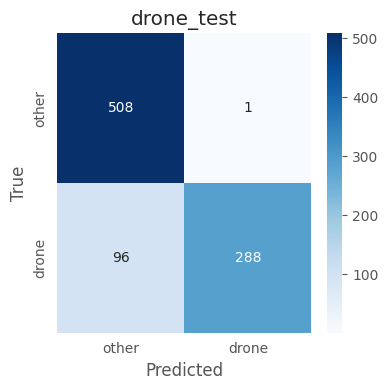

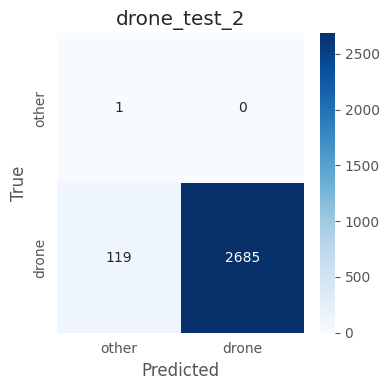

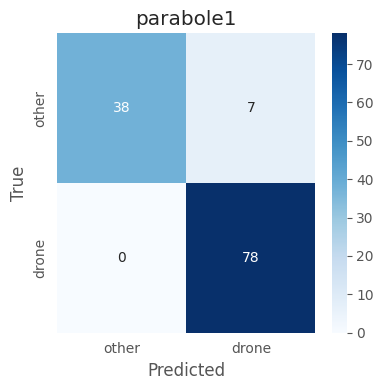

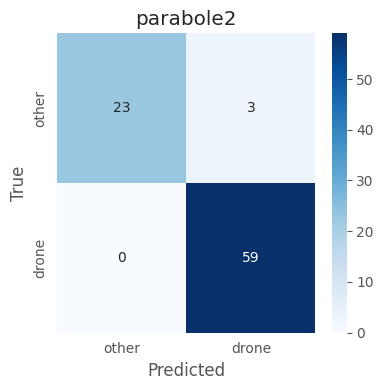

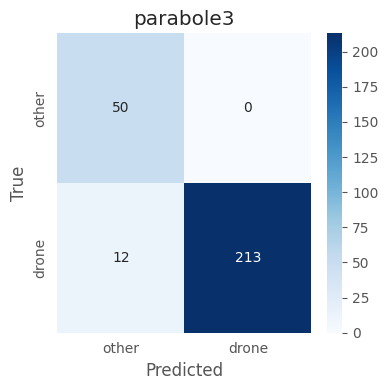

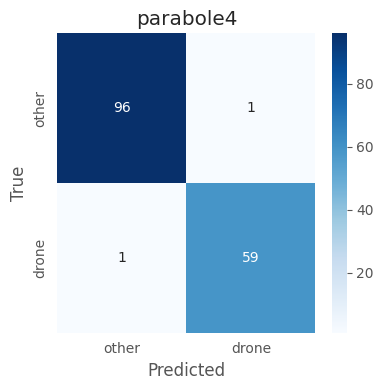

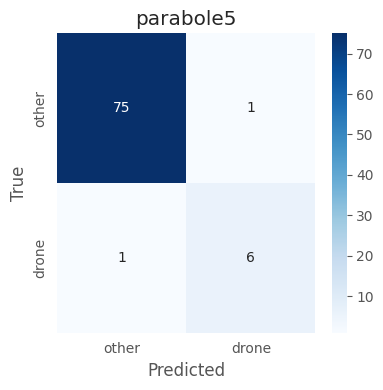

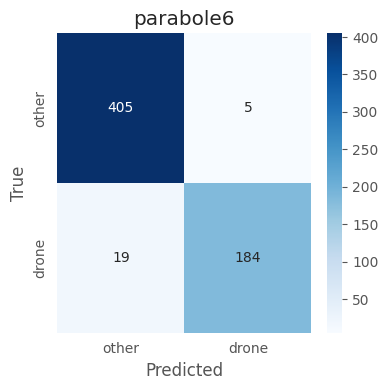

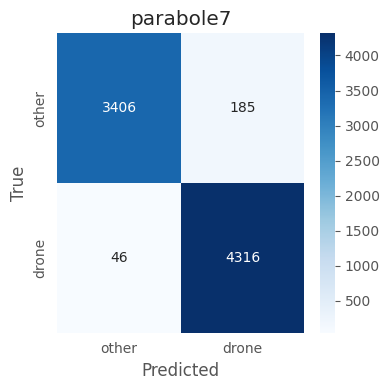

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

CLASS_NAMES = ["other", "drone"]

def plot_confusion(cm, title):
    plt.figure(figsize=(4,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for split, metric in metrics.items():
    plot_confusion(metric["confusion_matrix"], split)

## Custom Inference on WAV files

In [38]:
def infer_from_folder(folder_path: str):
    files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    results = []
    acc = 0

    for file in files:
        file_path = os.path.join(folder_path, file)
        waveform, sr = librosa.load(file_path, sr=16000)
        mel_spec = convert_to_mel_spectrogram(waveform).unsqueeze(0)
        mel_spec = mel_spec.to(DEVICE)

        with torch.no_grad():
            logits = model(mel_spec)
            probs = torch.sigmoid(logits).squeeze(1)
            pred = (probs > 0.5).float().cpu().item()
            confidence = probs.cpu().item()

        acc += pred
        print(file, int(pred), confidence)
        results.append({
            "file": file,
            "predicted_label": int(pred),
            "confidence": confidence
        })

    print("Acc: ", acc / len(files))

print(f"0 is {"other"}, 1 is {"drone"}")
infer_from_folder("/home/pierre/Documents/Projects/PST4/AI/data/raw/test/02-02-2026/other")

0 is other, 1 is drone
aigu_pierre1_chunk1.wav 0 0.0005339828785508871
aigu_pierre1_chunk2.wav 0 0.0014927483862265944
aigu_pierre1_chunk3.wav 0 0.008821159601211548
aigu_pierre1_chunk4.wav 0 0.00886490847915411
aigu_pierre1_chunk5.wav 0 0.011441527865827084
aigu_pierre1_chunk6.wav 0 0.02800755947828293
aigu_pierre1_chunk7.wav 0 0.018189633265137672
aigu_pierre1_chunk8.wav 0 0.041146695613861084
aigu_pierre1_chunk9.wav 0 0.13967904448509216
aigu_pierre1_chunk10.wav 0 0.002567353891208768
aigu_pierre1_chunk11.wav 0 0.017316071316599846
aigu_pierre1_chunk12.wav 0 0.0005677584558725357
aigu_pierre1_chunk13.wav 0 0.10360408574342728
aigu_pierre1_chunk14.wav 0 0.0032387757673859596
aigu_pierre1_chunk15.wav 0 0.037811242043972015
aigu_pierre1_chunk16.wav 0 0.1513659507036209
aigu_pierre1_chunk17.wav 0 0.0384947769343853
aigu_pierre1_chunk18.wav 0 0.015954336151480675
aigu_pierre1_chunk19.wav 0 0.00427636643871665
aigu_pierre1_chunk20.wav 0 0.018242094665765762
aigu_pierre1_chunk21.wav 0 0.00